In [2]:
import torch
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from transformer_lens import HookedTransformer
from tqdm import tqdm
import os
from pathlib import Path
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
import gc


/coc/pskynet6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/coc/pskynet6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/coc/pskynet6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` state

In [3]:
random.seed(42)

In [ ]:
from huggingface_hub import login
login(token="")

In [6]:
ds = load_dataset('newfacade/LeetCodeDataset', trust_remote_code=True)
hard_problems = [example for example in ds['train'] if example['difficulty'] == 'Hard']
print(f'Number of hard problems: {len(hard_problems)}')
problems = [(p['question_id'], p['problem_description'].split('\n\xa0')[0].replace('\xa0', " ")) for p in hard_problems 
            if len(p['problem_description'].split('\n\xa0')[0].split('.')) >= 5]
print(f'Number of hard problems with at least 5 sentences: {len(problems)}')

Number of hard problems: 606
Number of hard problems with at least 5 sentences: 501


In [ ]:
# dir_path = "leetcode/unclear_sentences"
# unclear_sentences = {}

# for file in tqdm(Path(dir_path).glob("*.txt")):
#     n = int(file.stem)  # "12.txt" -> 12

#     with file.open("r", encoding="utf-8") as f:
#         data = json.load(f)  # loads dict from file

#     # convert inner dict to list of (key, value) tuples
#     unclear_sentences[n] = list(data.items())



501it [00:05, 87.76it/s] 


In [7]:
dir_path = "leetcode/unclear_portion"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())



501it [00:06, 77.19it/s]


In [8]:
for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]

In [9]:
len(problems)

501

In [10]:
# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

In [11]:
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Dataset prepared with {len(questions)} total questions.")


Dataset prepared with 981 total questions.


In [12]:
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")

Dataset prepared with 501 total questions.
Number of ambiguous questions: 265
Number of clear questions: 236


In [13]:
model = HookedTransformer.from_pretrained(
    "meta-llama/Llama-3.1-8B-Instruct",
    device="cuda",
    torch_dtype=torch.float16 
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:44<00:00, 11.19s/it]


Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer


In [14]:
def format_question(question):
    messages = [
        {"role": "user", "content": question}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")

In [15]:
formatted_questions = [format_question(q) for q in questions]

In [16]:
activations = {layer: [] for layer in range(model.cfg.n_layers)}
attn_activations = {layer: [] for layer in range(model.cfg.n_layers)}
    
for prompt in tqdm(formatted_questions, desc="Processing prompts"):
    # Tokenize the prompt
    tokens = model.to_tokens(prompt, prepend_bos=False)
    
    # Define the hooks to capture MLP post-activations
    hook_points = [f"blocks.{layer}.hook_resid_post" for layer in range(model.cfg.n_layers)]
    attn_points = [f"blocks.{layer}.attn.hook_z" for layer in range(model.cfg.n_layers)]
    
    # Run the model and cache the activations
    _, cache = model.run_with_cache(tokens, names_filter=lambda name: name in hook_points + attn_points)
    
    # For each layer, store the activation of the LAST token
    for layer in range(model.cfg.n_layers):
        # Shape of cache[hook_point] is (batch, seq_len, d_mlp)
        # We take the activation of the last token [-1] as the sequence representation
        last_token_activation = cache[hook_points[layer]][0, :, :].mean(dim=0).detach().cpu().numpy()
        activations[layer].append(last_token_activation)
        attn_activations[layer].append(cache[attn_points[layer]].detach().cpu().numpy())
        
# Convert lists of activations to numpy arrays
for layer in range(model.cfg.n_layers):
    activations[layer] = np.array(activations[layer])

Processing prompts:   0%|                                                                                                                     | 0/501 [00:00<?, ?it/s]

Processing prompts: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 501/501 [00:59<00:00,  8.38it/s]


In [17]:
probe_accuracies = {}
probe_weights_by_layer = {}
y = np.array(labels)

for layer in tqdm(range(len(activations)), desc="Training Probes"):
    X = activations[layer]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=0
    )

    # Train a logistic regression probe
    probe = LogisticRegression(max_iter=5000, fit_intercept=False)
    probe.fit(X_train, y_train)
    
    # Evaluate the probe
    accuracy = probe.score(X_test, y_test)
    probe_accuracies[layer] = accuracy
    probe_weights_by_layer[layer] = probe.coef_

Training Probes: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:28<00:00,  1.12it/s]


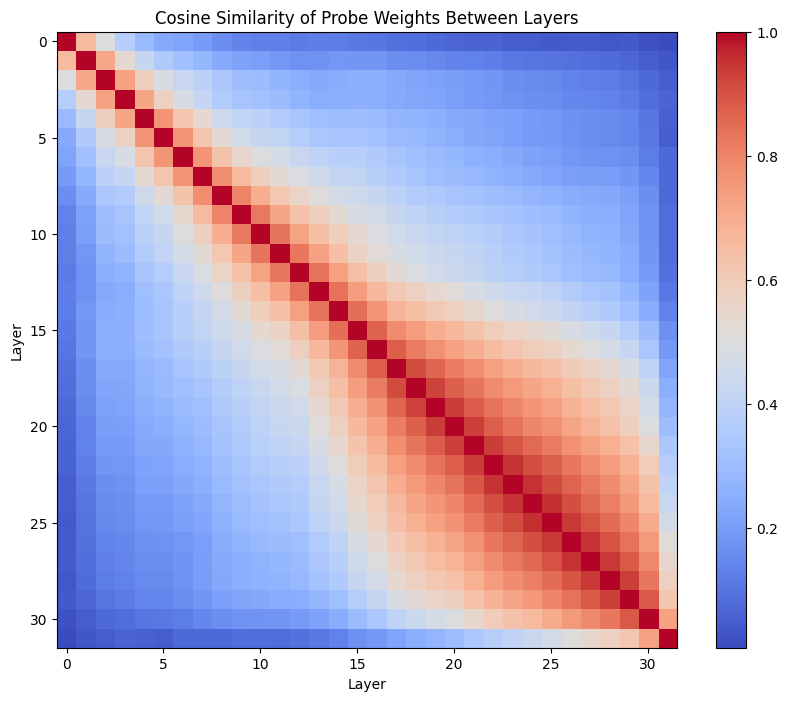

In [19]:
# probe_weights shape is (1, d_mlp) since it's a binary classification task with no intercept
# calculate cosine similarity of probe weights between each layer and visualize as heatmap
weight_matrix = np.zeros((model.cfg.n_layers, model.cfg.n_layers))
for i in range(model.cfg.n_layers):
    for j in range(model.cfg.n_layers):
        weight_matrix[i, j] = np.dot(probe_weights_by_layer[i][0].flatten(), probe_weights_by_layer[j][0].flatten()) / (np.linalg.norm(probe_weights_by_layer[i][0].flatten()) * np.linalg.norm(probe_weights_by_layer[j][0].flatten()))

plt.figure(figsize=(10, 8))
plt.imshow(weight_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xlabel('Layer')
plt.ylabel('Layer')
plt.title('Cosine Similarity of Probe Weights Between Layers')
plt.show()


In [18]:
idxs = np.arange(501)

train_idxs, test_idxs, _, _ = train_test_split(
    idxs, y, test_size=0.25, stratify=y, random_state=0
)

In [19]:
y = np.array(labels)
X = activations[15]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

# Train a logistic regression probe
probe = LogisticRegression(max_iter=1000, fit_intercept=False)
probe.fit(X_train, y_train)

# Evaluate the probe
accuracy = probe.score(X_test, y_test)
accuracy

0.9126984126984127

In [19]:
def get_ambiguity_attribution(model, prompt, layer, probe_weights, verbose=True, return_probe_score=False):
    """
    Performs gradient attribution to find which tokens contribute
    to the sparse probe's ambiguity score.
    """
    # 1. Clear any existing gradients
    model.zero_grad()

    # 2. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    
    # 3. Manually create the token embeddings
    token_embeds = model.embed(tokens).to(torch.float16)
    token_embeds.requires_grad_(True)
    
    # Tell PyTorch to save the gradient for this non-leaf tensor
    token_embeds.retain_grad()
    # -----------------------
    
    # 4. Create a dictionary to store our (non-detached) activation
    hook_storage = {}

    # 5. Define the hook function
    def cache_hook(activation_tensor, hook):
        # Store the tensor itself, which is still in the graph
        hook_storage[hook.name] = activation_tensor
        return activation_tensor # Pass it through unchanged

    # 6. Run the model using the .hooks() context manager
    hook_name = f"blocks.{layer}.hook_resid_post"
    with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
        # Run a standard forward pass.
        _ = model(token_embeds, start_at_layer=0) 

    # 7. Get AEN activations from our storage
    aen_activations = hook_storage[hook_name][0, -1, :]
        
    # 10. Calculate probe score 'S'
    S = torch.dot(aen_activations, probe_weights)

    if verbose:
        print(f"Probe score S: {S.item()}")
    
    # 11. Backpropagate
    S.backward()
    
    # 12. Get the gradients
    grads = token_embeds.grad[0] # Shape (seq_len, d_model)
    
    # 13. Calculate attribution score (Grad x Input)
    attribution_scores = torch.sum(grads * token_embeds[0], dim=1).detach().cpu().numpy()
    
    # 14. Get tokens for visualization
    str_tokens = model.to_str_tokens(tokens)
    
    if return_probe_score:
        return str_tokens, attribution_scores, S.item()
    
    return str_tokens, attribution_scores

In [20]:
def get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=5, verbose=True, baseline=None):
    model.zero_grad()

    # 1. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    
    token_embeds = model.embed(tokens).to(torch.float16).detach()
    
    # make the baseline the pad token id
    pad_token_id = model.tokenizer.pad_token_id

    if baseline is not None:
        baseline = baseline.unsqueeze(0).expand_as(token_embeds)
    else:
        baseline = model.embed(pad_token_id * torch.ones_like(tokens)).to(torch.float16).detach()

    total_grads = torch.zeros_like(token_embeds)

    alphas = torch.linspace(1/steps, 1, steps, device=token_embeds.device)

    hook_name = f"blocks.{layer}.hook_resid_post"

    for alpha in alphas:
        model.zero_grad()

        # 4. Interpolate embeddings
        scaled_embeds = baseline + alpha * (token_embeds - baseline)
        scaled_embeds.requires_grad_(True)
        scaled_embeds.retain_grad()

        hook_storage = {}

        # 5. Hook
        def cache_hook(activation_tensor, hook):
            hook_storage[hook.name] = activation_tensor
            return activation_tensor

        with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
            _ = model(scaled_embeds, start_at_layer=0)

        # 6. Probe score
        aen_activations = hook_storage[hook_name][0, -1, :]
        aen_activations = hook_storage[hook_name][0, :, :].mean(dim=0)
        S = torch.dot(aen_activations, probe_weights)

        # 7. Backprop
        S.backward()

        # 8. Accumulate gradients
        total_grads += scaled_embeds.grad

    if verbose:
        print("Probe Logit:" + str(S.item()))

    # 9. Average gradients
    avg_grads = total_grads / steps

    # 10. Integrated gradients
    ig = (token_embeds - baseline) * avg_grads

    # 11. Reduce over embedding dim → per-token score
    attribution_scores = ig[0].sum(dim=1).detach().cpu().numpy()

    str_tokens = model.to_str_tokens(tokens)

    return str_tokens, attribution_scores

In [21]:
import torch

def get_circuit_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=5, top_k=5):
    model.zero_grad()
    
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    seq_len = tokens.shape[1]
    
    probe_hook_name = f"blocks.{layer}.hook_resid_post"
    
    # ==========================================
    # STAGE 1: Identify Top-K Attention Heads
    # ==========================================
    clean_attn_scores = {}
    z_tensors = {}
    resid_storage = {}

    def hook_z_fwd(tensor, hook):
        tensor.retain_grad()
        z_tensors[hook.name] = tensor
        return tensor

    def hook_attn_scores_fwd(tensor, hook):
        clean_attn_scores[hook.name] = tensor.detach()
        return tensor

    def hook_resid_fwd(tensor, hook):
        resid_storage[hook.name] = tensor
        return tensor

    stage1_hooks = [(probe_hook_name, hook_resid_fwd)]
    for l in range(layer):
        stage1_hooks.append((f"blocks.{l}.attn.hook_z", hook_z_fwd))
        stage1_hooks.append((f"blocks.{l}.attn.hook_attn_scores", hook_attn_scores_fwd))

    with model.hooks(fwd_hooks=stage1_hooks):
        _ = model(tokens)

    aen_activations = resid_storage[probe_hook_name][0, -1, :]
    S = torch.dot(aen_activations, probe_weights)
    S.backward()

    head_scores = []
    for l in range(layer):
        z_grad = z_tensors[f"blocks.{l}.attn.hook_z"].grad 
        n_heads = z_grad.shape[2]
        for z in range(n_heads):
            head_grad = z_grad[0, :, z, :] 
            grad_norm = torch.linalg.norm(head_grad)
            head_scores.append((grad_norm.item(), l, z))

    head_scores.sort(reverse=True, key=lambda x: x[0])
    top_heads = [(l, z) for _, l, z in head_scores[:top_k]]
    
    # ==========================================
    # STAGE 2: Integrated Gradients on Attn Logits
    # ==========================================
    total_grads = { (l, z): torch.zeros((seq_len, seq_len), device="cuda") for l, z in top_heads }
    alphas = torch.linspace(1/steps, 1, steps, device="cuda")
    layers_to_hook = set(l for l, _ in top_heads)

    for alpha in alphas:
        model.zero_grad()
        intervened_logits = {}

        def make_attn_intervention_hook(l_target):
            def intervention_hook(tensor, hook):
                new_tensor = tensor.clone()
                for l, z in top_heads:
                    if l == l_target:
                        target_scores = clean_attn_scores[hook.name][0, z, :, :]
                        
                        # FIX 1: Preserve the causal mask during interpolation
                        is_masked = target_scores < -1e3
                        
                        # Scale only unmasked logits
                        scaled = torch.where(is_masked, target_scores, alpha * target_scores)
                        
                        scaled.requires_grad_(True)
                        scaled.retain_grad()
                        intervened_logits[(l, z)] = scaled
                        
                        new_tensor[0, z, :, :] = scaled
                return new_tensor
            return intervention_hook

        ig_hooks = [(probe_hook_name, hook_resid_fwd)]
        for l in layers_to_hook:
            ig_hooks.append((f"blocks.{l}.attn.hook_attn_scores", make_attn_intervention_hook(l)))

        with model.hooks(fwd_hooks=ig_hooks):
            _ = model(tokens)

        aen_activations = resid_storage[probe_hook_name][0, -1, :]
        S = torch.dot(aen_activations, probe_weights)
        S.backward()

        for l, z in top_heads:
            grad = intervened_logits[(l, z)].grad 
            total_grads[(l, z)] += grad

    print(f"Probe Logit (Final Alpha Step): {S.item():.4f}")

    # ==========================================
    # STAGE 3: Aggregate into Per-Token Scores
    # ==========================================
    per_token_attribution = torch.zeros(seq_len, device="cuda")

    for l, z in top_heads:
        avg_grad = total_grads[(l, z)] / steps
        target_scores = clean_attn_scores[f"blocks.{l}.attn.hook_attn_scores"][0, z, :, :]
        
        # FIX 2: Safely calculate IG matrix to avoid -inf * 0 = NaN
        is_masked = target_scores < -1e3
        ig_matrix = torch.where(
            is_masked, 
            torch.zeros_like(target_scores), 
            target_scores * avg_grad
        )
        
        A_i = ig_matrix.sum(dim=1)
        per_token_attribution += A_i

    attribution_scores = per_token_attribution.detach().cpu().numpy()
    str_tokens = model.to_str_tokens(tokens)

    return str_tokens, attribution_scores

In [22]:
# probe_weights = torch.tensor(probe.coef_[0]).to("cuda").to(torch.float16)
probe_weights = torch.tensor(probe_weights_by_layer[15][0]).to("cuda").to(torch.float16)

In [23]:
def plot_heatmap(tokens, scores, title="Ambiguity Attribution Heatmap", mask=None, normalize=True):
    """Plots a 1D heatmap of token attributions.
    Args:
        tokens: List of token strings
        scores: List of attribution scores (same length as tokens)
        title: Title for the plot
        mask: Optional binary mask to highlight certain tokens (e.g., ground-truth ambiguous tokens)
    """
    
    # Normalize scores from 0 to 1 for easier coloring
    scores_norm = scores
    if normalize:
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min())

    fig, ax = plt.subplots(figsize=(15, 2))   # ← define ax

    sns.heatmap(
        [scores_norm],
        xticklabels=tokens,
        yticklabels=False,
        cmap="Reds",
        annot=[[f"{s:.2f}" for s in scores]],
        fmt="",
        cbar=False,
        ax=ax                                  # ← pass ax
    )

    ax.set_title(title, fontsize=16)
    ax.set_xticklabels(tokens, rotation=45, ha="right")


    if mask is not None:
        mask = np.asarray(mask).astype(bool)
        for tick, m in zip(ax.get_xticklabels(), mask):
            if m:
                tick.set_color("blue")     # change color here
    # plt.tight_layout()
    plt.show()

In [ ]:
final_attribution = np.zeros_like(attributions[0])
for i in range(1,len(attributions)-1):
    # print(abs(int(sum(attributions[i] - attributions[i-1]))))
    # cosine similarity of consecutive attribution vectors
    b = np.dot(attributions[i], attributions[i-1]) / (np.linalg.norm(attributions[i]) * np.linalg.norm(attributions[i-1]))
    p = np.dot(attributions[i], attributions[i+1]) / (np.linalg.norm(attributions[i]) * np.linalg.norm(attributions[i+1]))
    final_attribution += attributions[i] * attributions[i-1]
    # print(b*p, b+p)
    # final_attribution += (b+p) * (attributions[i] - attributions[i-1]) #/ np.abs(sum(attributions[i] - attributions[i-1]))

In [ ]:
final_attribution = np.zeros_like(attributions[0])
for i in range(5,16):
    # print(abs(int(sum(attributions[i] - attributions[i-1]))))
    # cosine similarity of consecutive attribution vectors
    # b = np.dot(attributions[i], attributions[i-1]) / (np.linalg.norm(attributions[i]) * np.linalg.norm(attributions[i-1]))
    # p = np.dot(attributions[i], attributions[i+1]) / (np.linalg.norm(attributions[i]) * np.linalg.norm(attributions[i+1]))

    # softmax of attributions[i]
    final_attribution += softmax(attributions[i])

# final_attribution = softmax(final_attribution, temperature=len(final_attribution))

    # print(b*p, b+p)
    # final_attribution += (b+p) * (attributions[i] - attributions[i-1]) #/ np.abs(sum(attributions[i] - attributions[i-1]))

In [ ]:
final_attribution = np.zeros_like(attributions2[0])
for i in range(1,len(attributions2)-1):
    # print(abs(int(sum(attributions2[i] - attributions2[i-1]))))
    # cosine similarity of consecutive attribution vectors
    b = np.dot(attributions2[i], attributions2[i-1]) / (np.linalg.norm(attributions2[i]) * np.linalg.norm(attributions2[i-1]))
    p = np.dot(attributions2[i], attributions2[i+1]) / (np.linalg.norm(attributions2[i]) * np.linalg.norm(attributions2[i+1]))
    d = attributions2[i] * attributions2[i-1]
    final_attribution += d
    # print(b*p, b+p)
    # final_attribution += (attributions2[i] - attributions2[i-1]) #/ np.abs(sum(attributions2[i] - attributions2[i-1]))

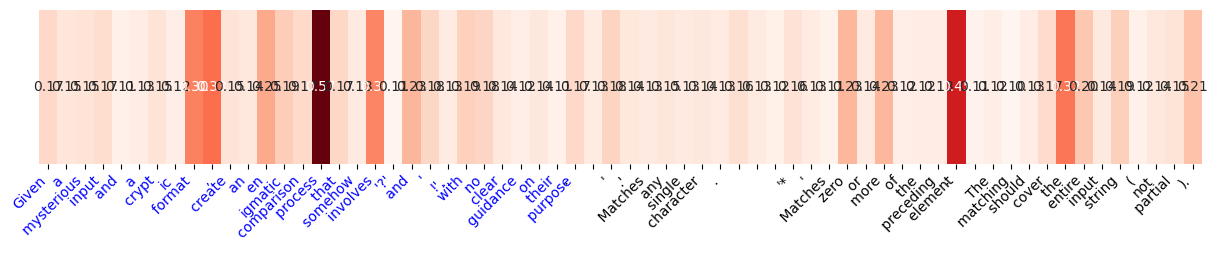

In [174]:
plot_heatmap(str_tokens, final_attribution, title=None, normalize=False, mask=mask)

In [25]:
def get_direct_attribution(model, prompt, layer, probe_weights, verbose=True):
    """
    Performs gradient attribution to find which tokens contribute
    to the sparse probe's ambiguity score.
    """
    # 1. Clear any existing gradients
    model.zero_grad()

    # 2. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    
    # 3. Manually create the token embeddings
    token_embeds = model.embed(tokens).to(torch.float16)
    token_embeds.requires_grad_(True)
    
    # Tell PyTorch to save the gradient for this non-leaf tensor
    token_embeds.retain_grad()
    # -----------------------
    
    # 4. Create a dictionary to store our (non-detached) activation
    hook_storage = {}

    # 5. Define the hook function
    def cache_hook(activation_tensor, hook):
        # Store the tensor itself, which is still in the graph
        hook_storage[hook.name] = activation_tensor
        return activation_tensor # Pass it through unchanged

    # 6. Run the model using the .hooks() context manager
    hook_name = f"blocks.{layer}.hook_resid_post"
    with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
        # Run a standard forward pass.
        _ = model(token_embeds, start_at_layer=0) 

    # 7. Get AEN activations from our storage
    aen_activations = hook_storage[hook_name][0, :, :] #shape (seq_len, d_mlp)

    # probe_weights shape is (1, d_mlp) since it's a binary classification task with no intercept
    # dot product of probe weights with each token's activation
    attribution_scores = torch.matmul(aen_activations, probe_weights.t()).squeeze().detach().cpu().numpy() # shape (seq_len,)
    
    str_tokens = model.to_str_tokens(tokens)
    
    return str_tokens, attribution_scores

In [26]:
def get_ambiguity_attribution_aggregated_ig( model, prompt, layer, probe_weights, steps=20, detach_attention=True, verbose=True, baseline=None):
    """
    Aggregated Integrated Gradients attribution for ambiguity probes.

    Instead of targeting only the last token's probe score, we define an
    aggregated target:

        s_tilde = sum_i alpha_i * (w . h_i^(l*))

    where alpha_i = softmax(w . h_i^(l*)) over all positions. This gives
    direct gradient paths from each token's embedding to its own residual
    stream projection, avoiding dilution through long-range attention mixing.

    The baseline is the mean embedding over the vocabulary, which is
    approximately probe-neutral and avoids the ambiguous-baseline problem
    that afflicts pad/zero baselines.

    Args:
        model:            TransformerLens model
        prompt:           Input string
        layer:            Layer index at which the probe was trained
        probe_weights:    Tensor of shape (d_model,) — linear probe weight vector
        steps:            Number of IG interpolation steps (default 20)
        detach_attention: If True, stop gradients through attention weights,
                          propagating only through value paths. This prevents
                          attribution from reflecting structural attention
                          patterns rather than semantic content. (default True)
        verbose:          Print probe logit if True
        baseline:         Optional custom baseline embedding of shape (d_model,).
                          If None, uses mean over the full embedding matrix.

    Returns:
        str_tokens:         List of string tokens
        attribution_scores: np.ndarray of shape (seq_len,)
    """
    model.zero_grad()

    # 1. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    token_embeds = model.embed(tokens).to(torch.float16).detach()  # (1, seq_len, d_model)

    # 2. Build baseline 
    pad_token_id = model.tokenizer.pad_token_id

    if baseline is not None:
        baseline = baseline.unsqueeze(0).expand_as(token_embeds)
    else:
        baseline = model.embed(pad_token_id * torch.ones_like(tokens)).to(torch.float16).detach()


    hook_name = f"blocks.{layer}.hook_resid_post"
    total_grads = torch.zeros_like(token_embeds)  # (1, seq_len, d_model)

    alphas = torch.linspace(1 / steps, 1, steps, device=token_embeds.device)

    # Track final probe score for verbose logging
    final_s_tilde = None

    for alpha in alphas:
        model.zero_grad()

        # 3. Interpolate embeddings along path from baseline to input
        scaled_embeds = baseline + alpha * (token_embeds - baseline)  # (1, seq_len, d_model)
        scaled_embeds = scaled_embeds.detach().requires_grad_(True)
        scaled_embeds.retain_grad()

        hook_storage = {}

        if detach_attention:
            # ----------------------------------------------------------------
            # Attention-detached forward pass.
            # We hook into each attention layer's pattern (the post-softmax
            # weights) and detach them from the graph, so that gradients flow
            # only through the value projection path and not through the
            # attention routing structure.
            # ----------------------------------------------------------------
            attn_hooks = [
                (f"blocks.{l}.attn.hook_pattern",
                 lambda tensor, hook: tensor.detach())
                for l in range(layer + 1)
            ]

            def cache_hook_detach(activation_tensor, hook):
                hook_storage[hook.name] = activation_tensor
                return activation_tensor

            all_hooks = attn_hooks + [(hook_name, cache_hook_detach)]

            with model.hooks(fwd_hooks=all_hooks):
                _ = model(scaled_embeds, start_at_layer=0)

        else:
            # ----------------------------------------------------------------
            # Standard forward pass — gradients flow through attention weights.
            # ----------------------------------------------------------------
            def cache_hook(activation_tensor, hook):
                hook_storage[hook.name] = activation_tensor
                return activation_tensor

            with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
                _ = model(scaled_embeds, start_at_layer=0)

        # 4. Residual stream at probe layer: (seq_len, d_model)
        resid = hook_storage[hook_name][0, :, :]  # (seq_len, d_model)

        # 5. Per-position probe scores: s_i = w . h_i^(l*)
        #    shape: (seq_len,)
        per_token_scores = torch.matmul(resid, probe_weights)

        # 6. Importance weights alpha_i = softmax over positions
        #    These upweight positions already carrying ambiguity signal.
        #    Detached so they act as fixed scalars in the gradient graph —
        #    we want gradients w.r.t. content, not w.r.t. the weighting itself.
        importance_weights = per_token_scores.detach()/per_token_scores.detach().sum()  # (seq_len,)

        # 7. Aggregated probe score: s_tilde = sum_i alpha_i * s_i
        s_tilde = (importance_weights * per_token_scores).sum()

        final_s_tilde = s_tilde

        # 8. Backprop through aggregated score
        s_tilde.backward()

        # 9. Accumulate gradients w.r.t. interpolated embeddings
        total_grads += scaled_embeds.grad  # (1, seq_len, d_model)

    if verbose and final_s_tilde is not None:
        print(f"Aggregated Probe Logit (s_tilde): {final_s_tilde.item():.4f}")

    # 10. Average gradients over interpolation steps
    avg_grads = total_grads / steps  # (1, seq_len, d_model)

    # 11. Integrated gradients: element-wise product of (input - baseline) and avg grad
    ig = (token_embeds - baseline) * avg_grads  # (1, seq_len, d_model)

    # 12. Sum over embedding dimension → per-token scalar attribution
    attribution_scores = ig[0].sum(dim=-1).detach().cpu().numpy()  # (seq_len,)

    str_tokens = model.to_str_tokens(tokens)

    return str_tokens, attribution_scores

In [27]:
# average over all tokens from corpus
baseline_token = torch.zeros(model.cfg.d_model, device="cuda", dtype=torch.float16)
total_tokens = 0

for prompt in questions:
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    embeds = model.embed(tokens)[0]
    
    baseline_token += embeds.sum(dim=0).detach()
    total_tokens += embeds.shape[0]

baseline_token /= total_tokens

In [28]:
baseline_token

tensor([-0.0014, -0.0021,  0.0009,  ...,  0.0003, -0.0008,  0.0009],
       device='cuda:0', dtype=torch.float16)

In [29]:
def get_ambiguity_attribution_new(model, prompt, layer, probe_weights, steps=25, verbose=True, baseline=baseline_token):
    model.zero_grad()

    # 1. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    T = tokens.shape[1]

    token_embeds = model.embed(tokens).to(torch.float16).detach()

    # Baseline: mean embedding across token positions in this prompt
    # (neutral, neither ambiguous nor unambiguous)
    baseline = baseline.unsqueeze(0).expand_as(token_embeds) # shape (T, d_model)

    total_grads = torch.zeros_like(token_embeds)

    alphas = torch.linspace(1/steps, 1, steps, device=token_embeds.device)

    hook_name = f"blocks.{layer}.hook_resid_post"

    # --- Compute attention rollout weights alpha_i = Phi(i -> T) ---
    # Collect attention matrices from all layers up to l*
    attn_pattern_hooks = [f"blocks.{l}.attn.hook_pattern" for l in range(layer + 1)]
    attn_v_hooks = [f"blocks.{l}.attn.hook_v" for l in range(layer + 1)] # [batch, pos, head, d_head]
    rollout_storage = {}

    def make_attn_hook(name):
        def hook(activation_tensor, hook):
            rollout_storage[name] = activation_tensor.detach()  # [batch, heads, T, T]
            return activation_tensor
        return hook

    attn_hooks = [(name, make_attn_hook(name)) for name in (attn_pattern_hooks + attn_v_hooks)]

    with torch.no_grad():
        with model.hooks(fwd_hooks=attn_hooks):
            _ = model(token_embeds, start_at_layer=0)

    # Compute rollout: average over heads, then multiply across layers
    # rollout[i] = how much token i attends into position T after composing all layers
    rollout = torch.eye(T, device="cuda", dtype=torch.float32)  # [T, T]
    # print(rollout_storage[attn_hook_names[0]][0][:,:,0])
    for l in range(layer-3,layer + 1):
        attn = rollout_storage[attn_pattern_hooks[l]][0].float()  # [heads, T, T]
        avg_attn = attn.mean(dim=0)                    # [T, T]
        # avg_attn[:, 0] = 0  # zero out attention into BOS token if present
        # Add residual connection: 0.5 * identity + 0.5 * attention (standard rollout)
        avg_attn = 0.5 * avg_attn + 0.5 * torch.eye(T, device="cuda", dtype=torch.float32)
        avg_attn = avg_attn / avg_attn.sum(dim=-1, keepdim=True)  # renormalize rows
        rollout = avg_attn @ rollout  # compose

    # alpha_i = rolled-out attention weight from position i to last token T
    alpha_weights = rollout[-1, :]  # [T] — how much each position flows into T
    alpha_weights = alpha_weights / alpha_weights.sum()  # normalize to simplex
    print("Attention Rollout Weights (alpha_i):", alpha_weights.cpu().numpy())
    # alpha_weights = torch.ones(T, device="cuda", dtype=torch.float32) / T

    # --- Integrated gradients against the weighted probe target s_tilde ---
    for alpha in alphas:
        model.zero_grad()

        scaled_embeds = baseline + alpha * (token_embeds - baseline)
        scaled_embeds.requires_grad_(True)
        scaled_embeds.retain_grad()

        hook_storage = {}

        def cache_hook(activation_tensor, hook):
            hook_storage[hook.name] = activation_tensor
            return activation_tensor

        with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
            _ = model(scaled_embeds, start_at_layer=0)

        # Probe score at ALL positions, weighted by rollout alpha_i
        # s_tilde = sum_i alpha_i * (w . h_i^{l*})
        # Shape: [T]
        all_activations = hook_storage[hook_name][0]         # [T, d]
        per_token_scores = all_activations @ probe_weights   # [T]
        S_tilde = (alpha_weights * per_token_scores).sum()   # scalar

        S_tilde.backward()
        total_grads += scaled_embeds.grad

    if verbose:
        # Also report the original single-token probe score for reference
        with torch.no_grad():
            hook_storage_ref = {}
            def ref_hook(activation_tensor, hook):
                hook_storage_ref[hook.name] = activation_tensor
                return activation_tensor
            with model.hooks(fwd_hooks=[(hook_name, ref_hook)]):
                _ = model(token_embeds, start_at_layer=0)
            S_original = torch.dot(hook_storage_ref[hook_name][0, -1, :], probe_weights)
        print(f"Original probe logit (last token): {S_original.item():.4f}")
        print(f"Weighted probe logit (s_tilde):    {S_tilde.item():.4f}")

    # Average and compute IG
    avg_grads = total_grads / steps
    ig = (token_embeds - baseline) * avg_grads

    # Per-token score: sum over embedding dim
    attribution_scores = ig[0].sum(dim=1).detach().cpu().numpy()

    # Optionally expose the decomposition: local encoding vs causal reach
    local_scores = attribution_scores                              # full IG score
    causal_weights = alpha_weights.detach().cpu().numpy()         # alpha_i per token

    str_tokens = model.to_str_tokens(tokens)

    return str_tokens, attribution_scores#, causal_weights

In [30]:
def get_ambiguity_attribution_aggregated_ig(model, prompt, layer, probe_weights, steps=20, verbose=True, baseline=None):
    # 1. Clear any existing gradients
    model.zero_grad()

    # 2. Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")
    
    # 3. Manually create the token embeddings
    token_embeds = model.embed(tokens).to(torch.float16)
    token_embeds.requires_grad_(True)
    
    # Tell PyTorch to save the gradient for this non-leaf tensor
    token_embeds.retain_grad()
    # -----------------------

    
    total_grads = torch.zeros_like(token_embeds)

    alphas = torch.linspace(1/steps, 1, steps, device=token_embeds.device)

    hook_name = f"blocks.{layer}.hook_resid_post"

    for alpha in alphas:
        model.zero_grad()

        # 4. Interpolate embeddings
        scaled_embeds = baseline + alpha * (token_embeds - baseline)
        scaled_embeds = scaled_embeds.detach().requires_grad_(True)
        scaled_embeds.retain_grad()

        hook_storage = {}

        # 5. Hook
        def cache_hook(activation_tensor, hook):
            hook_storage[hook.name] = activation_tensor
            return activation_tensor

        with model.hooks(fwd_hooks=[(hook_name, cache_hook)]):
            _ = model(scaled_embeds, start_at_layer=0)

        # 6. Probe score
        aen_activations = hook_storage[hook_name][0, :, :] #shape (seq_len, d_mlp)
        attribution_weights = torch.matmul(aen_activations, probe_weights) #shape (seq_len,)
        # attribution_weights = attribution_weights / attribution_weights.sum() # normalize to simplex
        # # print("Attribution weights (w . h_i):", attribution_weights.detach().cpu().numpy())
        # S = attribution_weights.mean(dim=0) # aggregate over positions

        S = torch.dot(aen_activations.mean(dim=0), probe_weights) 

        # aen_activations = hook_storage[hook_name][0, -1, :]
        # pro = torch.dot(aen_activations, probe_weights)

        # 7. Backprop
        S.backward()

        # 8. Accumulate gradients
        total_grads += scaled_embeds.grad.detach()

    # if verbose:
    #     print("Probe Logit:" + str(S.item()))

    # 9. Average gradients
    avg_grads = total_grads / steps

    # 10. Integrated gradients
    ig = (token_embeds - baseline) * avg_grads

    # 11. Reduce over embedding dim → per-token score
    attribution_scores = ig[0].sum(dim=1).detach().cpu().numpy()

    str_tokens = model.to_str_tokens(tokens)




    return str_tokens, attribution_scores

In [31]:
def get_ambiguity_mid_layer_ig(model, prompt, layer, attribution_layer, probe_weights, steps=20, verbose=True, baseline=None):
    model.zero_grad()

    tokens = model.to_tokens(prompt, prepend_bos=False).to("cuda")

    # -------------------------------
    # 1. Get residual stream at attribution_layer (l0)
    # -------------------------------
    hook_l0 = f"blocks.{attribution_layer}.hook_resid_post"
    hook_storage = {}

    def cache_l0(activation, hook):
        hook_storage[hook.name] = activation.detach()
        return activation

    with model.hooks(fwd_hooks=[(hook_l0, cache_l0)]):
        _ = model(tokens)

    resid_l0 = hook_storage[hook_l0]  # shape: (1, seq, d_model)
    resid_l0 = resid_l0.detach().requires_grad_(True)
    resid_l0.retain_grad()

    # -------------------------------
    # 2. Baseline in residual space
    # -------------------------------
    if baseline is None:
        baseline = torch.zeros_like(resid_l0)

    total_grads = torch.zeros_like(resid_l0)

    alphas = torch.linspace(1/steps, 1, steps, device=resid_l0.device)

    hook_probe = f"blocks.{layer}.hook_resid_post"

    # -------------------------------
    # 3. IG loop in residual space
    # -------------------------------
    for alpha in alphas:
        model.zero_grad()

        scaled_resid = baseline + alpha * (resid_l0 - baseline)
        scaled_resid = scaled_resid.detach().requires_grad_(True)
        scaled_resid.retain_grad()

        hook_storage = {}

        def cache_probe(activation, hook):
            hook_storage[hook.name] = activation
            return activation

        with model.hooks(fwd_hooks=[(hook_probe, cache_probe)]):
            _ = model(
                scaled_resid,
                start_at_layer=attribution_layer
            )

        # -------------------------------
        # 4. Probe score at layer l*
        # -------------------------------
        h_probe = hook_storage[hook_probe][0]  # (seq, d_model)

        # Same aggregation as before
        S = torch.dot(h_probe.mean(dim=0), probe_weights)

        # -------------------------------
        # 5. Backprop ONLY to resid_l0
        # -------------------------------
        S.backward()

        total_grads += scaled_resid.grad.detach()

    # -------------------------------
    # 6. Integrated gradients in residual space
    # -------------------------------
    avg_grads = total_grads / steps
    ig = (resid_l0 - baseline) * avg_grads

    # -------------------------------
    # 7. Reduce to per-token attribution
    # -------------------------------
    attribution_scores = ig[0].sum(dim=1).detach().cpu().numpy()
    str_tokens = model.to_str_tokens(tokens)

    return str_tokens, attribution_scores

In [33]:
def softmax(x, temperature=1.0):
    e_x = np.exp((x - np.max(x)) / temperature)
    return e_x / e_x.sum()

In [43]:
span_auroc(scores, mask)

0.8239866194411649

In [ ]:
for end in range(8,21,2):
    for start in range(6,17,2):
        if start > end:
            continue
        layer=end
        probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
        # prompt = format_question("""It's unclear what that means""")
        mask = None
        prompt, _, mask = pairs[7]
        # str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=100, baseline=baseline_token)
        # str_tokens, scores = get_ambiguity_attribution_new(model, prompt, layer, probe_weights)
        # str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
        # str_tokens, scores = get_ambiguity_attribution_aggregated_ig(model, prompt, layer, probe_weights, steps=100, baseline=baseline_token)
        str_tokens, scores = get_ambiguity_mid_layer_ig(model, prompt, layer, attribution_layer=start, probe_weights=probe_weights, steps=100, baseline=None)
        # str_tokens, scores = str_tokens[10:-5], gaussian_smooth(scores[10:-5].astype(np.float32), sigma=3)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5].astype(np.float32)
        mask = mask[10:-5] if mask is not None else None
        plot_heatmap(str_tokens, scores, title=None, normalize=False, mask=mask)
        print(start, end)
        print("Span AUROC:", span_auroc(scores, mask))
        print("Span AUROC w smoothing 1.5:", span_auroc(gaussian_smooth(scores, sigma=1.5), mask))
        print("Span AUROC w smoothing 3:", span_auroc(gaussian_smooth(scores, sigma=3), mask))

In [ ]:
layer=14
probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
# prompt = format_question("""It's unclear what that means""")
prompt = """Write a 1,000-word essay analyzing the impact of social media on modern communication, including both positive and negative effects. Be sure to reference at least two real-world examples to support your argument. Explain how people are affected by it in ways that depend on factors. Conclude by discussing potential future developments and their implications."""
prompt = format_question(prompt)
mask = None
# prompt, _, mask = pairs[6]
# str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=100, baseline=baseline_token)
# str_tokens, scores = get_ambiguity_attribution_new(model, prompt, layer, probe_weights)
# str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
# str_tokens, scores = get_ambiguity_attribution_aggregated_ig(model, prompt, layer, probe_weights, steps=100, baseline=baseline_token)
str_tokens, scores = get_ambiguity_mid_layer_ig(model, prompt, layer, attribution_layer=12, probe_weights=probe_weights, steps=50, baseline=None)
# str_tokens, scores = str_tokens[10:-5], gaussian_smooth(scores[10:-5].astype(np.float32), sigma=3)
str_tokens, scores = str_tokens[10:-5], scores[10:-5].astype(np.float32)
mask = mask[10:-5] if mask is not None else None
plot_heatmap(str_tokens, scores, title=None, normalize=False, mask=mask)
plot_heatmap(str_tokens, gaussian_smooth(scores, sigma=1.5), title=None, normalize=False, mask=mask)
plot_heatmap(str_tokens, gaussian_smooth(scores, sigma=3), title=None, normalize=False, mask=mask)
plot_heatmap(str_tokens, gaussian_smooth(scores, sigma=5), title=None, normalize=False, mask=mask)
print("Span AUROC:", span_auroc(scores, mask))
print("Span AUROC w smoothing 1.5:", span_auroc(gaussian_smooth(scores, sigma=1.5), mask))
print("Span AUROC w smoothing 3:", span_auroc(gaussian_smooth(scores, sigma=3), mask))

In [ ]:
attributions = {}
for layer in range(model.cfg.n_layers):
    print(f"Layer {layer} probe accuracy: {probe_accuracies[layer]:.4f}")
    probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
    # prompt = format_question("""That question is so ambiguous, I have no idea what it means""")
    mask = None
    prompt, _, mask = pairs[0]
    # str_tokens, scores = get_circuit_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=50, top_k=10)
    # str_tokens, scores = get_ambiguity_attribution(model, prompt, layer, probe_weights)
    # str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=25, baseline=baseline_token)
    str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
    print(span_auroc(scores[10:-5], mask[10:-5]))
    # str_tokens, scores = get_ambiguity_attribution_aggregated_ig(model, prompt, layer, probe_weights, steps=30, baseline=baseline_token)
    str_tokens, scores = get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=25, baseline=baseline_token)
    str_tokens, scores = str_tokens[10:-5], scores[10:-5]
    mask = mask[10:-5] if mask is not None else None
    plot_heatmap(str_tokens, scores, title=None, normalize=False, mask=mask)
    print(span_auroc(scores, mask))
    # plot_heatmap(str_tokens, softmax(scores), title=None, normalize=False, mask=mask)
    # print(span_auroc(softmax(scores), mask))
    attributions[layer] = scores

In [82]:
# run the above attribution code for all layers and store results in a file for later analysis
options = [(12,14), (10,12), (13,15), (12,16), (16,20), (8,10), (8,12), (18,20)]
for start_layer, end_layer in options:
    results = {}
    for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
        pid, pdesc = problems[idx]
        if pid not in unclear_sentences:
            continue
        prompt, _, mask = generate_mask(pid, pdesc)
        mask = mask[10:-5]
        
        probe_weights = torch.tensor(probe_weights_by_layer[end_layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_ambiguity_mid_layer_ig(model, prompt, end_layer, attribution_layer=start_layer, probe_weights=probe_weights, steps=50, baseline=None)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions = scores.tolist()
        
        results[idx] = {
            "pid": pid,
            "pdesc": pdesc,
            "tokens": str_tokens,
            "attributions": attributions,
            "mask": mask.tolist(),
            "label": int(y_test[i])
        }
        # Save intermediate results to file after each layer
        with open(f"mid_layer_{start_layer}_{end_layer}_attribution_results.json", "w") as f:
            json.dump(results, f)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 126/126 [04:37<00:00,  2.20s/it]


In [ ]:
# run the above attribution code for all layers and store results in a file for later analysis
results = {}
for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
    pid, pdesc = problems[idx]
    if pid not in unclear_sentences:
        continue
    prompt, _, mask = generate_mask(pid, pdesc)
    mask = mask[10:-5]
    
    attributions = {}
    for layer in range(model.cfg.n_layers):
        probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions[layer] = scores.tolist()
    
    results[idx] = {
        "pid": pid,
        "pdesc": pdesc,
        "tokens": str_tokens,
        "attributions": attributions,
        "mask": mask.tolist(),
        "label": int(y_test[i])
    }
    # Save intermediate results to file after each layer
    with open("attribution_results.json", "w") as f:
        json.dump(results, f)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 126/126 [05:40<00:00,  2.70s/it]


In [165]:
# same as above, but uses clear samples
results = {}
for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
    pid, pdesc = problems[idx]
    if pid not in unclear_sentences:
        continue
    prompt, _, mask = generate_mask_clear(pid, pdesc)
    mask = mask[10:-5]
    
    attributions = {}
    for layer in range(model.cfg.n_layers):
        probe_weights = torch.tensor(probe_weights_by_layer[layer][0]).to("cuda").to(torch.float16)
        str_tokens, scores = get_direct_attribution(model, prompt, layer, probe_weights)
        str_tokens, scores = str_tokens[10:-5], scores[10:-5]
        attributions[layer] = scores.tolist()
    
    results[idx] = {
        "pid": pid,
        "pdesc": pdesc,
        "tokens": str_tokens,
        "attributions": attributions,
        "mask": mask.tolist(),
        "label": int(y_test[i])
    }
    # Save intermediate results to file after each layer
    with open("attribution_results_clear.json", "w") as f:
        json.dump(results, f)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 126/126 [04:58<00:00,  2.37s/it]


In [110]:
# read the results back from file and analyze
with open("attribution_results.json", "r") as f:
    results = json.load(f)

In [48]:
with open("mid_layer_8_10_attribution_results.json", "r") as f:
    results = json.load(f)

In [109]:
options = [(8,10),(8,12), (10,12), (12,14),  (13,15), (12,16)]#, (16,20),  (18,20)]
for start_layer, end_layer in options:
    print(f"{start_layer}-{end_layer} attribution scores:")
    with open(f"mid_layer_{start_layer}_{end_layer}_attribution_results.json", "r") as f:
        results = json.load(f)
    # scores averaged over group of layers
    scores = []
    raw_attributions = []
    for idx, data in results.items():

        attribution = np.array(data["attributions"])
        mask = np.array(data["mask"])
        
        raw_attributions.append((attribution, data["mask"]))

        #If I randomly pick one token from inside the span and one from outside, 
        # what’s the probability the inside token gets a higher attribution score?
        # score = span_auroc(gaussian_smooth(attribution, sigma=1), mask)

        p = mask.sum() / len(mask)
        score = attribution_auprc(gaussian_smooth(attribution, sigma=3), mask)
        score = (score -p) / (1-p)


        scores.append(score)

    scores = np.array(scores)
    print(scores.mean(), scores.std())

8-10 attribution scores:
0.4089818071539488 0.365567328889169
8-12 attribution scores:
0.5761844960954434 0.3292696412319564
10-12 attribution scores:
0.33328986169512426 0.25479773558572016
12-14 attribution scores:
0.6726665459176548 0.28284396269299994
13-15 attribution scores:
0.707327979186128 0.29915027612752987
12-16 attribution scores:
0.765281050107195 0.2537062310222334


In [91]:
#median of scores
print(np.median(scores))

0.8334414532275845


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  2.,  1.,  2.,  2.,  1.,  2.,  1.,
         3.,  1.,  2.,  2.,  5.,  5.,  6.,  5.,  9., 14., 19., 35.]),
 array([0.53389831, 0.55254237, 0.57118644, 0.58983051, 0.60847458,
        0.62711864, 0.64576271, 0.66440678, 0.68305085, 0.70169492,
        0.72033898, 0.73898305, 0.75762712, 0.77627119, 0.79491525,
        0.81355932, 0.83220339, 0.85084746, 0.86949153, 0.88813559,
        0.90677966, 0.92542373, 0.9440678 , 0.96271186, 0.98135593,
        1.        ]),
 <BarContainer object of 25 artists>)

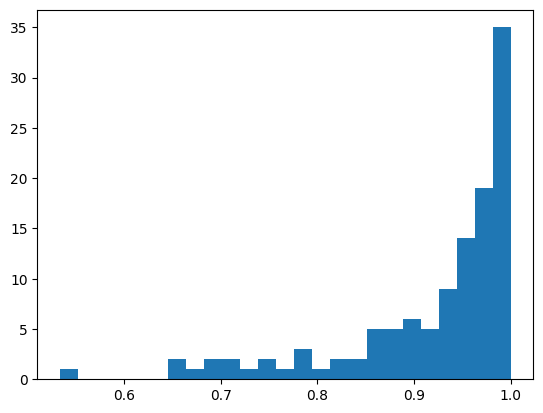

In [153]:
# make a histogram of scores, the data is stored in "scores"

plt.hist(scores, bins=25)

In [155]:
# scores averaged over group of layers
scores = []
raw_attributions = []
for idx, data in results.items():

    attribution = np.zeros_like(data["attributions"]["0"])
    for layer in range(4,16):
        layer_attribution = np.array(data["attributions"][str(layer)])
        attribution += layer_attribution / np.linalg.norm(layer_attribution)

    mask = np.array(data["mask"])
    raw_attributions.append((attribution, mask))

    #If I randomly pick one token from inside the span and one from outside, 
    # what’s the probability the inside token gets a higher attribution score?
    attribution = gaussian_smooth(attribution, sigma=3)
    score = span_auroc(attribution, mask)

    score = (score - 0.5) / 0.5
    
    # p = mask.sum() / len(mask)
    # score = attribution_auprc(attribution, mask)
    # score = (score -p) / (1-p)

    scores.append(score)

scores = np.array(scores)
# mean and std of scores
print(f"Mean score: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")

Mean score: 0.8395, Std: 0.1873


In [65]:
# scores by layer
scores_by_layer = [[] for _ in range(model.cfg.n_layers)]
for idx, data in results.items():
    for layer in range(0,32):
        attribution = np.array(data["attributions"][str(layer)])
        attribution = attribution / np.linalg.norm(attribution)
        scores_by_layer[layer].append(span_auroc(attribution, data["mask"]))

scores_by_layer = np.array(scores_by_layer)

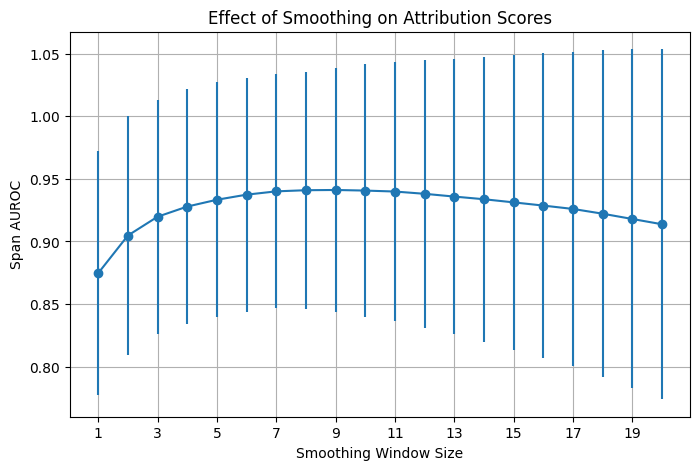

In [68]:
max_sm = 20
smoothed_scores = []
for sm in range(1, max_sm + 1):
    for a, mask in raw_attributions:
        # attribution = smooth_attribution(a, sm)
        attribution = gaussian_smooth(a, sigma=sm)
        smoothed_scores.append(span_auroc(attribution, mask))

    # mean and std of smoothed_scores for this smoothing window size
    # mean_score = np.mean(smoothed_scores)
    # std_score = np.std(smoothed_scores)
    # print(f"Smoothing window size: {sm}, Mean Span AUROC: {mean_score}, Std Span AUROC: {std_score}")

# plot the mean and std of smoothed_scores for each smoothing window size
smoothed_scores = np.array(smoothed_scores).reshape(max_sm, -1)
mean_scores = smoothed_scores.mean(axis=1)
std_scores = smoothed_scores.std(axis=1)
plt.figure(figsize=(8, 5))
plt.errorbar(range(1, max_sm + 1), mean_scores, yerr=std_scores, fmt='-o')
plt.xlabel('Smoothing Window Size')
plt.ylabel('Span AUROC')
plt.title('Effect of Smoothing on Attribution Scores')
plt.xticks(range(1, max_sm + 1, max(1, max_sm // 10)))
plt.grid()
plt.show()


In [33]:
# smooth attribution scores with a Gaussian kernel
from scipy.ndimage import gaussian_filter1d
def gaussian_smooth(attribution, sigma=3):
    attribution = np.array(attribution)
    return gaussian_filter1d(attribution, sigma=sigma)

In [34]:
# smooth attribution scores by averaging with neighboring token positions
def smooth_attribution(attribution, kernel_size=3):
    """Smooths attribution scores by averaging with neighboring tokens."""
    smoothed = np.zeros_like(attribution)
    pad = kernel_size // 2
    padded = np.pad(attribution, (pad, pad), mode='edge')
    
    for i in range(len(attribution)):
        smoothed[i] = padded[i:i+kernel_size].mean()
    
    return smoothed

In [175]:
s = smooth_attribution(attribution, sum(data['mask']))
len(s), len(attribution)

(115, 115)

In [184]:
for sm in range(1, 10):
    # smoothed = smooth_attribution(attribution, kernel_size=sm)
    smoothed = gaussian_smooth(attribution, sigma=sm)
    score = span_auroc(smoothed, data["mask"])
    print(f"Kernel size: {sm}, Span AUC: {score:.4f}")

Kernel size: 1, Span AUC: 0.8536
Kernel size: 2, Span AUC: 0.9046
Kernel size: 3, Span AUC: 0.9444
Kernel size: 4, Span AUC: 0.9686
Kernel size: 5, Span AUC: 0.9794
Kernel size: 6, Span AUC: 0.9780
Kernel size: 7, Span AUC: 0.9769
Kernel size: 8, Span AUC: 0.9769
Kernel size: 9, Span AUC: 0.9766


In [186]:
s = gaussian_smooth(attribution, sigma=3)
span_auc(s, data['mask'])

np.float64(0.9444444444444444)

In [189]:
pdesc

'You are given a string s, an integer k, a letter letter, and an integer repetition.\nReturn the lexicographically smallest subsequence of s of length k that has the letter letter appear at least repetition times. The test cases are generated so that the letter appears in s at least repetition times.\nA subsequence is a string that can be derived from another string by deleting some or no characters without changing the order of the remaining characters.\nA string a is lexicographically smaller than a string b if in the first position where a and b differ, string a has a letter that appears earlier in the alphabet than the corresponding letter in b.'

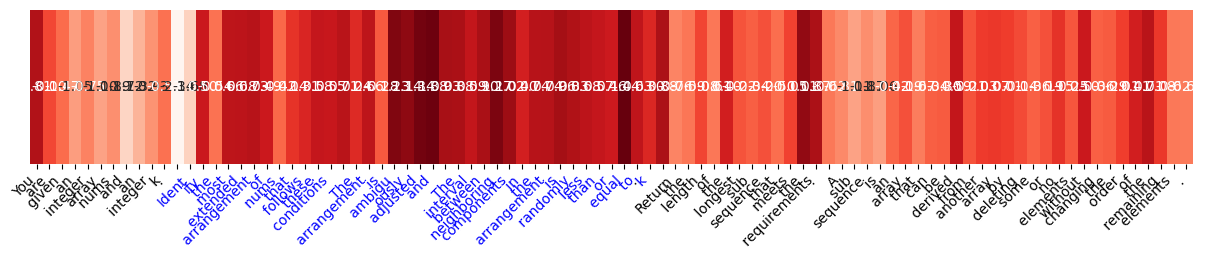

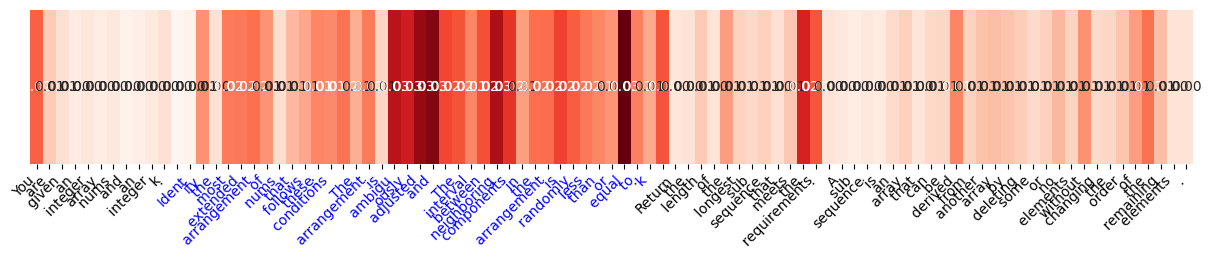

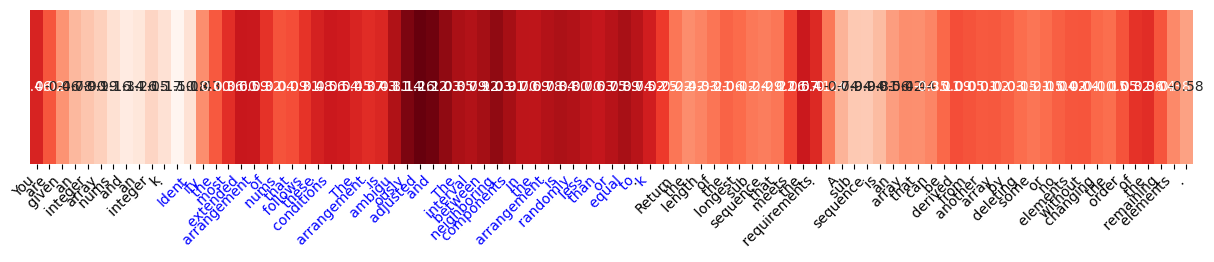

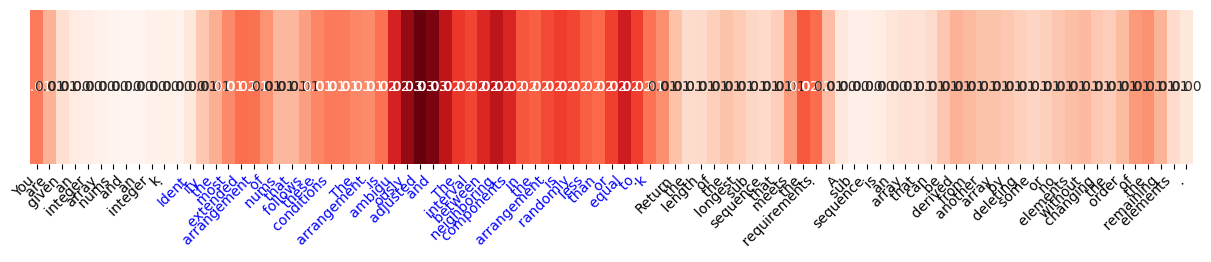

In [187]:
idx, data = list(results.items())[1]
# print(f"PID: {data['pid']}, Label: {data['label']}")
attribution = np.zeros_like(data["attributions"]["0"])
for layer in range(4,16):
    layer_attribution = np.array(data["attributions"][str(layer)])
    attribution += layer_attribution / np.linalg.norm(layer_attribution)

plot_heatmap(data["tokens"], attribution, title=None, mask=data["mask"],normalize=False)
plot_heatmap(data["tokens"], softmax(attribution), title=None, mask=data["mask"],normalize=False)
sigma = 1
s = gaussian_smooth(attribution, sigma=sigma)
plot_heatmap(data["tokens"], s, title=None, mask=data["mask"],normalize=False)
s = gaussian_smooth(softmax(attribution), sigma=sigma)
plot_heatmap(data["tokens"], s, title=None, mask=data["mask"],normalize=False)


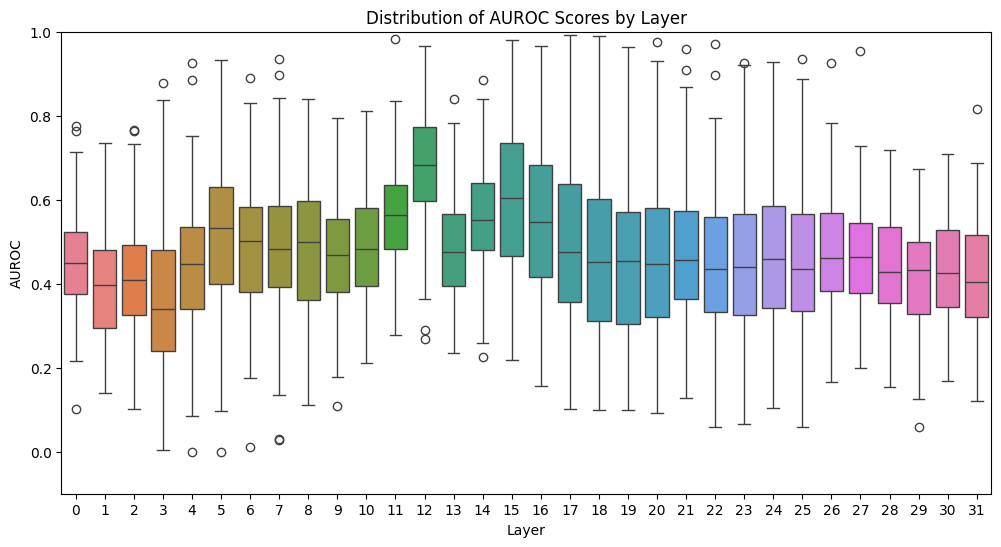

In [188]:
# plot boxplot of scores by layer
plt.figure(figsize=(12, 6))
sns.boxplot(data=scores_by_layer.T, )
plt.xlabel("Layer")
plt.ylabel("AUROC")
# limit y-axis to -0.1 to 0.1
plt.ylim(-.1, 1)
plt.title("Distribution of AUROC Scores by Layer")
plt.show()

In [159]:
unclear_sentences[pid]

[('Return an array times where times[i] is the time when all nodes get marked in the tree, if you mark node i at time t = 0.',
  'Provide a list of moments when every point in the structure becomes highlighted, assuming point i is highlighted at the beginning.')]

In [35]:
def generate_mask(pid, pdesc):
    if pid not in unclear_sentences:
        return None
    
    clr, unclr = unclear_sentences[pid][0]
    new_problem = format_question(pdesc.replace(clr, unclr))
    
    # 1. Find the character start/end of the 'unclr' string in the new text
    char_start = new_problem.find(unclr)
    char_end = char_start + len(unclr)
    
    # 2. Tokenize the full sentence
    # Note: Use return_offsets_mapping to see which chars belong to which tokens
    tokens_dict = model.tokenizer(
        new_problem, 
        return_offsets_mapping=True, 
        return_tensors="pt",
        add_special_tokens=False
    )
    
    tokenized = tokens_dict['input_ids'][0]
    offsets = tokens_dict['offset_mapping'][0] # List of (char_start, char_end) for each token
    
    # 3. Create the mask
    mask = torch.zeros_like(tokenized)
    for i, (start, end) in enumerate(offsets):
        # Check if the token overlaps with our target character range
        # We check if the token's range is within the unclr range
        if start >= char_start and end <= char_end and start != end:
            mask[i] = 1

    # apply the mask to tokenized input ids to get the unclr portion's token ids
    # unclr_token_ids = tokenized[mask == 1]
    # decoded_unclr = model.tokenizer.batch_decode(unclr_token_ids)
            
    return (new_problem, unclr, mask)

In [36]:
def generate_mask_clear(pid, pdesc):
    if pid not in unclear_sentences:
        return None
    
    clr, unclr = unclear_sentences[pid][0]
    problem = pdesc
    
    # 1. Find the character start/end of the 'clr' string in the new text
    char_start = problem.find(clr)
    char_end = char_start + len(clr)
    
    # 2. Tokenize the full sentence
    # Note: Use return_offsets_mapping to see which chars belong to which tokens
    tokens_dict = model.tokenizer(
        problem, 
        return_offsets_mapping=True, 
        return_tensors="pt",
        add_special_tokens=False
    )
    
    tokenized = tokens_dict['input_ids'][0]
    offsets = tokens_dict['offset_mapping'][0] # List of (char_start, char_end) for each token
    
    # 3. Create the mask
    mask = torch.zeros_like(tokenized)
    for i, (start, end) in enumerate(offsets):
        # Check if the token overlaps with our target character range
        # We check if the token's range is within the clr range
        if start >= char_start and end <= char_end and start != end:
            mask[i] = 1

    # apply the mask to tokenized input ids to get the clr portion's token ids
    # clr_token_ids = tokenized[mask == 1]
    # decoded_clr = model.tokenizer.batch_decode(clr_token_ids)
            
    return (problem, clr, mask)

In [37]:
pairs = []
for pid, pdesc in problems:
    res = generate_mask(pid, pdesc)
    if res is not None:        
        pairs.append(res)

In [62]:
import torch
import nltk

DEBUG = False 

pairs = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    
    clr, unclr = unclear_sentences[pid][0]
    new_problem = pdesc.replace(clr, unclr)
    
    unclr_start_char = new_problem.find(unclr)
    if unclr_start_char == -1:
        print(f"Warning: '{unclr}' not found in new_problem for pid {pid}.")
        continue
    unclr_end_char = unclr_start_char + len(unclr)
    
    before_text = new_problem[:unclr_start_char]
    after_text = new_problem[unclr_end_char:]
    
    sentences_before = nltk.sent_tokenize(before_text) if before_text.strip() else []
    sentences_after = nltk.sent_tokenize(after_text) if after_text.strip() else []
    
    custom_sentences = sentences_before + [unclr] + sentences_after
    unclear_slice_idx = len(sentences_before)
    
    tokens_dict = model.tokenizer(
        new_problem, 
        return_offsets_mapping=True, 
        return_tensors="pt",
        add_special_tokens=False
    )
    
    tokenized = tokens_dict['input_ids'][0]
    offsets = tokens_dict['offset_mapping'][0].tolist()
    
    sentence_slices = []
    search_start_char = 0
    last_tok_idx = 0  # <--- NEW: Locks the boundary so chunks can't claim the same token
    
    for chunk in custom_sentences:
        char_start = new_problem.find(chunk, search_start_char)
        char_end = char_start + len(chunk)
        search_start_char = char_end 
        
        tok_start = None
        tok_end = None
        
        # <--- NEW: We only check tokens that haven't been claimed by previous chunks
        for j in range(last_tok_idx, len(offsets)):
            o_start, o_end = offsets[j]
            if o_start == o_end: 
                continue 
            
            # Check overlap
            if o_start < char_end and o_end > char_start:
                if tok_start is None:
                    tok_start = j
                tok_end = j + 1 
            
            # Optimization: If the token starts after our chunk ends, we can stop looking
            elif o_start >= char_end:
                break
        
        # Fallback if no tokens overlapped (e.g., chunk was completely skipped)
        if tok_start is None:
            tok_start, tok_end = last_tok_idx, last_tok_idx
            
        sentence_slices.append((tok_start, tok_end))
        
        # <--- NEW: Update the boundary lock for the next iteration
        last_tok_idx = tok_end  

    # --- Generate the true decoded strings from our slices ---
    decoded_sentences = []
    for tok_start, tok_end in sentence_slices:
        # Decode the exact slice to get the ground-truth text
        true_text = model.tokenizer.decode(tokenized[tok_start:tok_end])
        decoded_sentences.append(true_text)

    if DEBUG:
        print(f"\n--- Verifying Problem ID: {pid} ---")
        for i, (tok_start, tok_end) in enumerate(sentence_slices):
            reconstructed_text = model.tokenizer.decode(tokenized[tok_start:tok_end])
            marker = "  <-- [TARGET UNCLEAR SENTENCE]" if i == unclear_slice_idx else ""
            
            print(f"Chunk {i}{marker}")
            print(f"  Expected Text: {repr(custom_sentences[i])}")
            print(f"  Decoded Tokens:{repr(reconstructed_text)}")
            print(f"  Token Slice:   [{tok_start}:{tok_end}]")

    pairs.append({
        'new_problem': new_problem,
        'tokenized_ids': tokenized,
        'intended_sentences': custom_sentences,  # What we asked for
        'decoded_sentences': decoded_sentences,  # What we actually got
        'sentence_slices': sentence_slices,
        'unclear_slice_idx': unclear_slice_idx
    })

In [43]:
pairs[0]

("<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nGiven a mysterious input and a cryptic format, create an enigmatic comparison process that somehow involves '?' and '!', with no clear guidance on their purpose.\n\n'.' Matches any single character.\u200b\u200b\u200b\u200b\n'*' Matches zero or more of the preceding element.\n\nThe matching should cover the entire input string (not partial).<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",
 "Given a mysterious input and a cryptic format, create an enigmatic comparison process that somehow involves '?' and '!', with no clear guidance on their purpose.",
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0]))

In [23]:
model.tokenizer.decode(pairs[0]['tokenized_ids'][0:31])

"Given a mysterious input and a cryptic format, create an enigmatic comparison process that somehow involves '?' and '!', with no clear guidance on their purpose.\n\n"

In [34]:
prompt = formatted_questions[102]
prompt, _, mask = pairs[2]

prompt = """You are given a string s and an array of strings words. All the strings of words are of the same length.
A concatenated string is a string that exactly contains all the strings of any permutation of words concatenated.

For example, if words = ["ab","cd","ef"], then "abcdef", "abefcd", "cdabef", "cdefab", "efabcd", and "efcdab" are all concatenated strings. "acdbef" is not a concatenated string because it is not the concatenation of any permutation of words.

Generate a list of the initial positions of each mixed-up piece found in the place. You can list them however you feel like. You can return the answer in any order."""
prompt = format_question(prompt)

# prompt = format_question("Which bat is the best?")
layer = 15
str_tokens, scores = get_ambiguity_attribution(model, prompt, layer, probe_weights)

Probe score S: -0.458984375


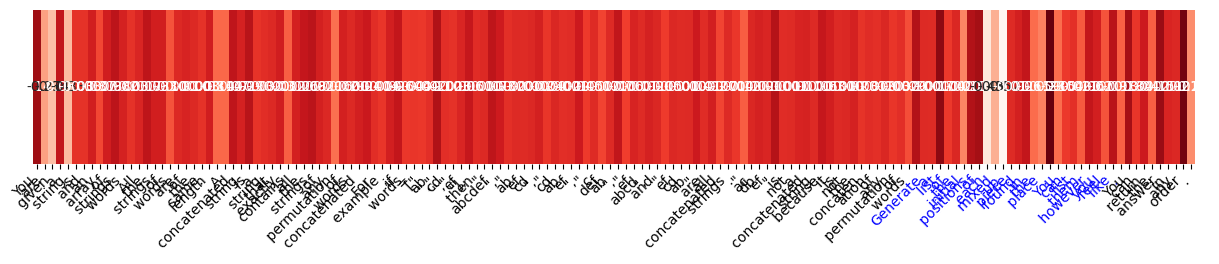

In [26]:
str_tokens, scores, mask = str_tokens[10:-5], scores[10:-5], mask[10:-5]
plot_heatmap(str_tokens, scores, title=None, mask=mask)

In [28]:
def format_question_unclear(question):
    messages = [
        {"role": "user", "content": question},
        {"role": "assistant", "content": "This question is unclear."}
    ]
    text = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    return text.replace("Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n", "")
    

In [54]:
print(pairs[2][0])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

<|eot_id|><|start_header_id|>user<|end_header_id|>

You are given a string s and an array of strings words. All the strings of words are of the same length.
A concatenated string is a string that exactly contains all the strings of any permutation of words concatenated.

For example, if words = ["ab","cd","ef"], then "abcdef", "abefcd", "cdabef", "cdefab", "efabcd", and "efcdab" are all concatenated strings. "acdbef" is not a concatenated string because it is not the concatenation of any permutation of words.

Generate a list of the initial positions of each mixed-up piece found in the place. You can list them however you feel like. You can return the answer in any order.<|eot_id|><|start_header_id|>assistant<|end_header_id|>




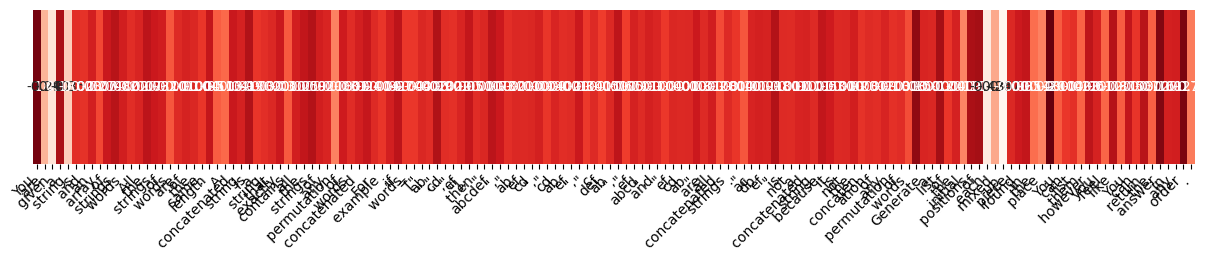

In [101]:
str_tokens, scores = str_tokens[10:-5], scores[10:-5]
plot_heatmap(str_tokens, scores, title=None)

In [63]:
results = []
for i in tqdm(range(len(pairs))):
    prompt, sentence_slices, unclear_slice_idx = format_question(pairs[i]['new_problem']), pairs[i]['sentence_slices'], pairs[i]['unclear_slice_idx']
    # str_tokens, scores = get_ambiguity_attribution(model, prompt, layer, probe_weights, verbose=False)
    str_tokens, scores, probe_score = get_ambiguity_attribution(model, prompt, layer, probe_weights, verbose=False, return_probe_score=True)
    str_tokens, scores = str_tokens[10:-5], scores[10:-5]
    ratio, rank, total = unclear_sentence_rank_topk(scores, sentence_slices, unclear_slice_idx)
    results.append((rank, total, probe_score))
    # print(rank, total)
    # plot_heatmap(str_tokens, scores, title=None)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 480/480 [01:11<00:00,  6.69it/s]


In [178]:
len(results)

NameError: name 'results' is not defined

In [ ]:
# get the average rank for each total sentence count
from collections import defaultdict
rank_by_sentence_count = defaultdict(list)
for rank, total, probe_score in results:
    rank_by_sentence_count[total].append(rank)

print("Average Rank by Sentence Count (sorted):")
for total in sorted(rank_by_sentence_count.keys()):
    avg_rank = sum(rank_by_sentence_count[total]) / len(rank_by_sentence_count[total])
    print(f"  {total}: {avg_rank:.2f}")


In [ ]:
# get the average rank for each total sentence count
from collections import defaultdict
rank_by_sentence_count = defaultdict(list)
for rank, total, probe_score in results:
    rank_by_sentence_count[total].append(rank)

print("Average Rank by Sentence Count (sorted):")
for total in sorted(rank_by_sentence_count.keys()):
    avg_rank = sum(rank_by_sentence_count[total]) / len(rank_by_sentence_count[total])
    print(f"  {total}: {avg_rank:.2f}")


In [69]:
ranks, totals, probe_scores = zip(*results)

In [73]:
max(probe_scores)

10.40625

In [77]:
sum(list(ranks))/len(ranks)

1.29375

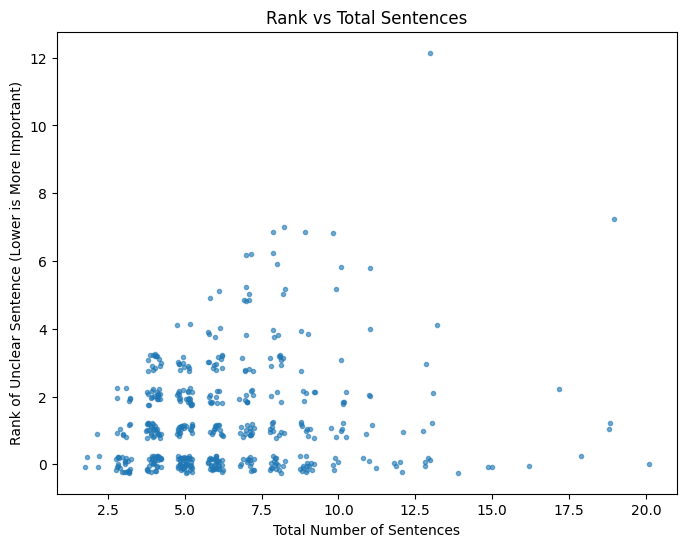

In [81]:
# plot rank vs total
import numpy as np

ranks, totals, probe_scores = zip(*results)

jitter_strength = 0.25  # tune this

x_jittered = np.array(totals) + np.random.uniform(-jitter_strength, jitter_strength, len(totals))
# x_jittered = np.array(probe_scores)
y_jittered = np.array(ranks) + np.random.uniform(-jitter_strength, jitter_strength, len(ranks))

plt.figure(figsize=(8, 6))
plt.plot(x_jittered, y_jittered, '.', alpha=0.6)
plt.xlabel("Total Number of Sentences")
plt.ylabel("Rank of Unclear Sentence (Lower is More Important)")
plt.title("Rank vs Total Sentences")
plt.show()

In [40]:
results = np.array(results)
print(f"Average Ratio: {results.mean():.4f} ± {results.std():.4f}")

Average Ratio: 0.2002 ± 0.2140


In [ ]:
results = np.array(results)
print(f"Average Ratio: {results.mean():.4f} ± {results.std():.4f}")

Average Ratio: 0.4426 ± 0.2659


In [161]:
results = np.array(results)
print(f"Average Ratio: {results.mean():.4f} ± {results.std():.4f}")

Average Ratio: 0.4089 ± 0.3142


Probe Logit (Final Alpha Step): 3.5527
0.5368587658001351
2.5541015
0.5524931148776792


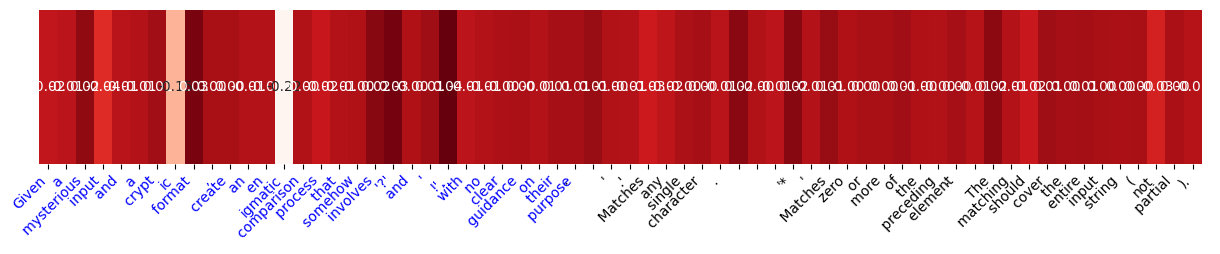

Probe Logit (Final Alpha Step): 7.1641
0.2723394073812909
1.0999027
0.23095077224571917


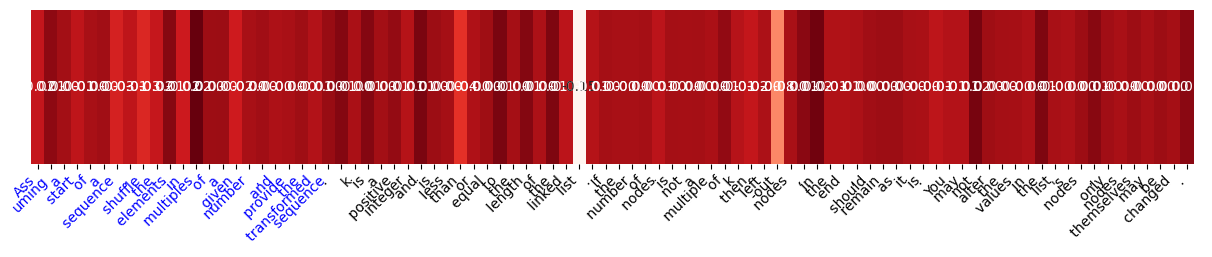

Probe Logit (Final Alpha Step): 3.6406
0.3011885933405719
4.145682
0.4349990530404749


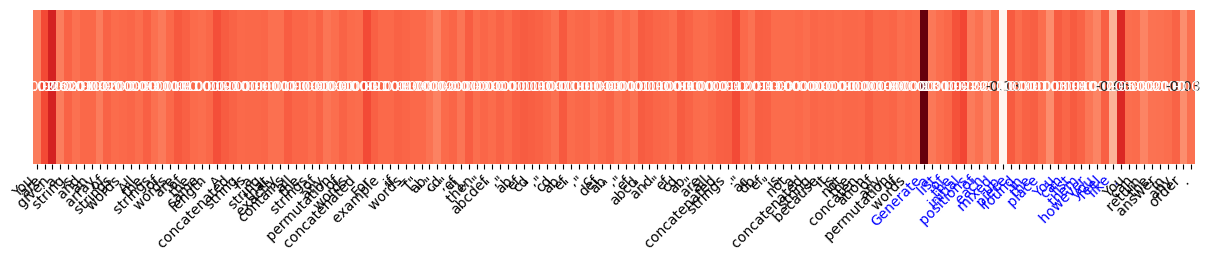

Probe Logit (Final Alpha Step): 3.1230
0.681764450113789
0.40271473
0.5383102411999799


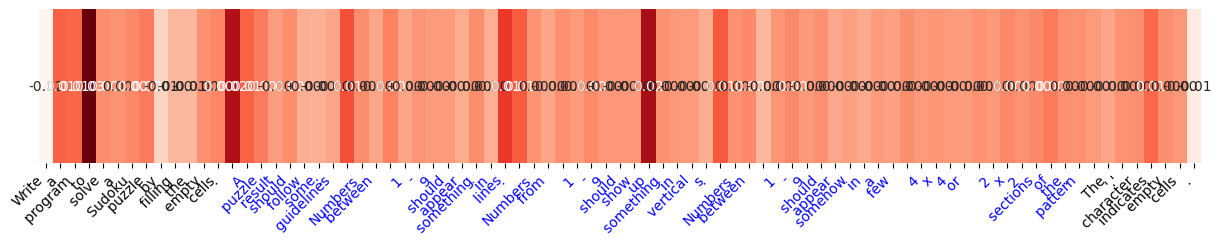

Probe Logit (Final Alpha Step): 2.3770
0.35738145405416444
1.8456863
0.3545290948130315


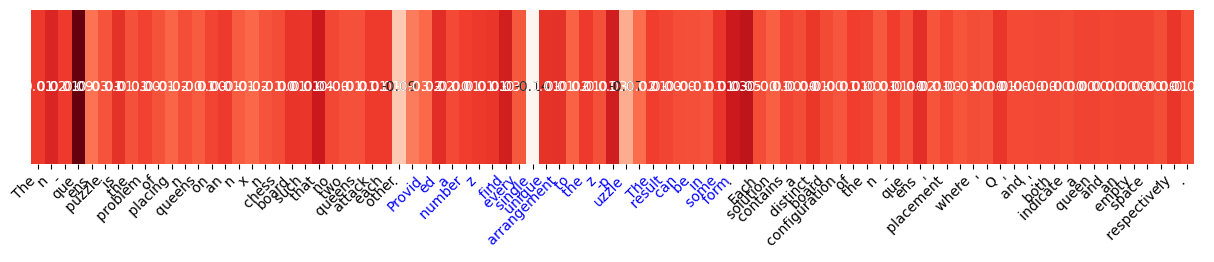

Probe Logit (Final Alpha Step): 3.1055
0.20034430260611077
2.1713262
0.20070012401778456


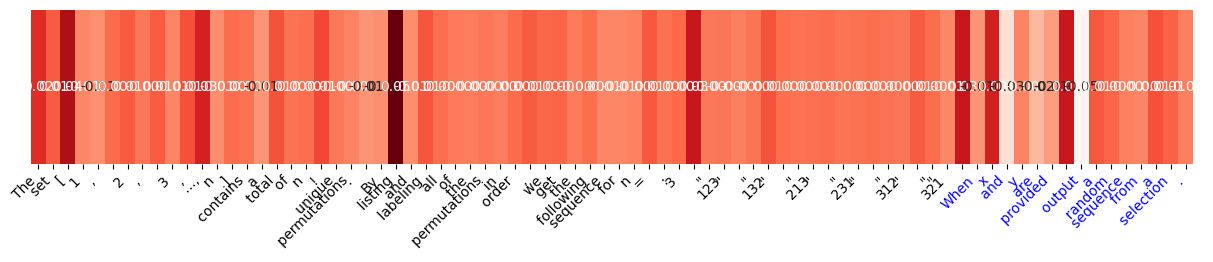

Probe Logit (Final Alpha Step): 2.3574
0.13778220248091955
5.4226804
0.15792651387099435


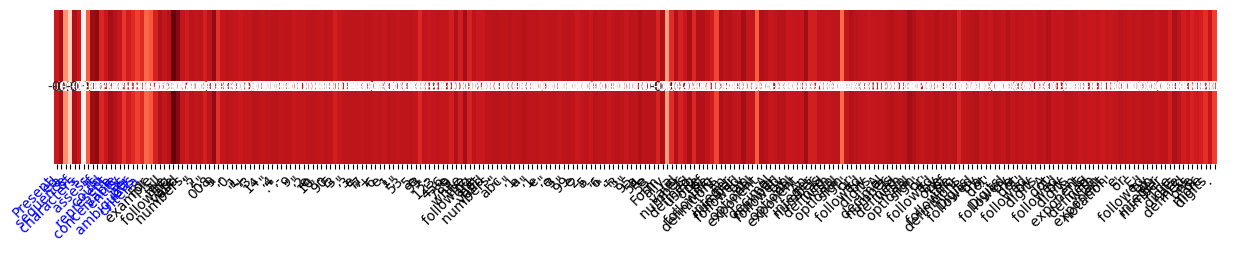

Probe Logit (Final Alpha Step): 2.4434
0.26937773613280613
1.5076923
0.3578633997786176


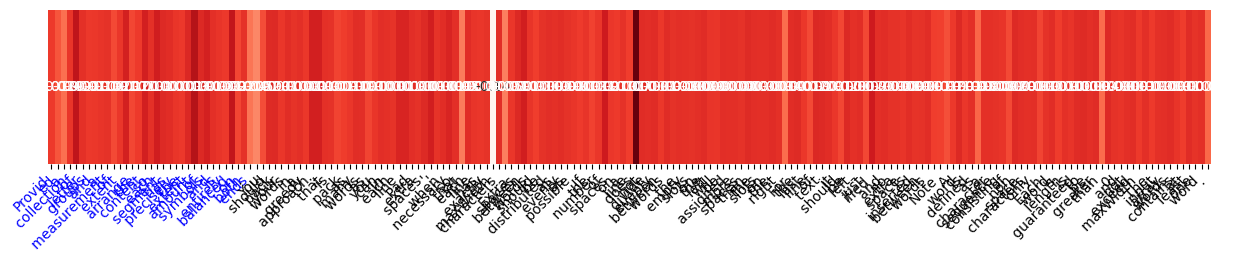

Probe Logit (Final Alpha Step): 6.5195
0.2867237275040986
1.546511
0.31562667779907294


/coc/pskynet6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/coc/pskynet6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


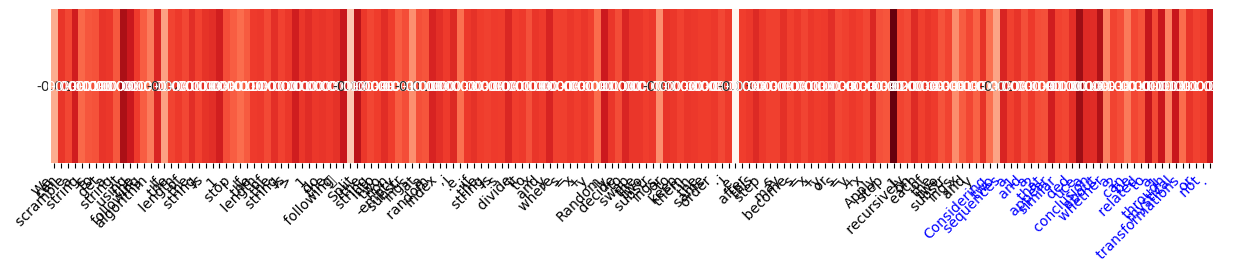

Probe Logit (Final Alpha Step): 1.3760
0.31263887342103713
3.9432309
0.2702318524377936


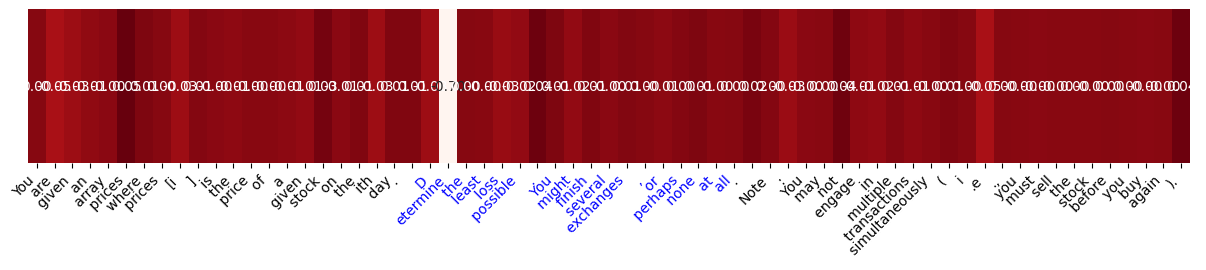

In [103]:
for i in range(10):
    prompt, _, mask = pairs[i]
    str_tokens, scores = get_circuit_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=25, top_k=5) #get_ambiguity_attribution_ig(model, prompt, layer, probe_weights, steps=25)
    str_tokens, scores, mask = str_tokens[10:-5], scores[10:-5], mask[10:-5]
    print(attribution_auprc(scores, mask))
    print(span_enrichment(scores, mask))
    print(mass_in_span(scores, mask))
    plot_heatmap(str_tokens, scores, title=None, mask=mask)

In [70]:
from sklearn.metrics import average_precision_score

def attribution_auprc(scores: np.ndarray, mask: np.ndarray) -> float:
    scores = np.asarray(scores).reshape(-1)
    mask = np.asarray(mask).reshape(-1)

    return average_precision_score(mask, scores)

In [38]:
from sklearn.metrics import roc_auc_score

def span_auroc(scores, mask):
    scores = np.asarray(scores)
    mask = np.asarray(mask).astype(int)

    return roc_auc_score(mask, scores)

In [33]:
def mass_in_span(scores: np.ndarray, mask: np.ndarray) -> float:
    scores = np.asarray(scores).reshape(-1)
    mask = np.asarray(mask).reshape(-1)
    scores = np.clip(scores, a_min=0, a_max=None)

    total = scores.sum() + 1e-12
    inside = (scores * mask).sum()
    return inside / total

In [34]:
def prob_lift(normalized_scores: np.ndarray, mask: np.ndarray) -> float:
    scores = (np.asarray(normalized_scores).reshape(-1))
    mask = np.asarray(mask).reshape(-1)

    prob_in_span = (scores * mask).sum()
    expected_prob_in_span = float(mask.sum()) / len(scores)
    # print(f"Prob in span: {prob_in_span:.4f}, Expected prob in span: {expected_prob_in_span:.4f}")

    return ((prob_in_span - expected_prob_in_span) / (1 - expected_prob_in_span), prob_in_span, expected_prob_in_span)

In [35]:
def span_enrichment(scores, mask):
    scores = np.abs(np.asarray(scores))
    mask = np.asarray(mask).astype(bool)

    inside = scores[mask].mean()
    outside = scores[~mask].mean() + 1e-12

    return inside / outside

In [36]:
def ranking_logistic_loss(a, mask):
    a, mask = torch.tensor(a), mask
    pos = a[mask == 1]
    neg = a[mask == 0]

    diff = pos[:, None] - neg[None, :]
    loss = torch.log1p(torch.exp(-diff)).mean()
    return loss

In [37]:
def unclear_sentence_rank(scores, sentence_slices, unclear_slice_idx):
    scores = np.asarray(scores)
    losses = []
    for i, (start, end) in enumerate(sentence_slices):
        sentence_score = scores[start:end].mean() if end > start else 0.0
        label = 1 if i == unclear_slice_idx else 0
        losses.append((sentence_score, label))
    
    losses.sort(key=lambda x: x[0], reverse=True)
    
    # return the rank of the unclear sentence (0-based)
    for rank, (_, label) in enumerate(losses, start=0):
        if label == 1:
            ratio = rank / len(losses)
            return ratio, rank, len(losses)

In [38]:
def unclear_sentence_rank_topk(scores, sentence_slices, unclear_slice_idx, k=3):
    scores = np.asarray(scores)
    losses = []
    for i, (start, end) in enumerate(sentence_slices):
        slice_scores = scores[start:end]
        
        n_tokens = len(slice_scores)
        percentage = int(0.5 * n_tokens)
        actual_k = max(percentage, min(k, n_tokens))
        
        top_k_values = np.partition(slice_scores, -actual_k)[-actual_k:]
        sentence_score = top_k_values.mean()

        label = 1 if i == unclear_slice_idx else 0
        losses.append((sentence_score, label))
    
    losses.sort(key=lambda x: x[0], reverse=True)
    
    for rank, (score, label) in enumerate(losses):
        if label == 1:
            ratio = rank / len(losses) if len(losses) > 0 else 0
            return ratio, rank, len(losses)

In [42]:
import numpy as np

def span_auc(scores, mask):
    scores = np.asarray(scores)
    mask = np.asarray(mask).astype(bool)

    in_scores = scores[mask]
    out_scores = scores[~mask]

    total = 0.0
    count = 0

    for s_in in in_scores:
        total += np.sum(s_in > out_scores)
        total += 0.5 * np.sum(s_in == out_scores)
        count += len(out_scores)

    return total / count if count > 0 else np.nan

In [39]:
str_tokens = ["Which", "bat", "is", "the", "best", "?"]
scores = np.array([0.1, 1.8, -0.2, 0.3, 0.5, -0.1])
mask = np.array([0, 1, 0, 0, 1, 0])
scores = np.abs(scores)
print(attribution_auprc(scores, mask))
print(span_auroc(scores, mask))
print(span_enrichment(scores, mask))
print(mass_in_span(scores, mask))
print(ranking_logistic_loss(scores, mask))

1.0
1.0
6.571428571391019
0.766666666666411
tensor(0.3624, dtype=torch.float64)


In [21]:
def get_conflict_heads(model, tokens, layer, probe_weights, top_k=4):

    z_storage = {}
    resid_storage = {}

    def cache_z(z, hook):
        z.retain_grad()
        z_storage["z"] = z
        return z

    def cache_resid(resid, hook):
        resid_storage["resid"] = resid
        return resid

    hooks = [
        (f"blocks.{layer}.attn.hook_z", cache_z),
        (f"blocks.{layer}.hook_resid_post", cache_resid),
    ]

    with model.hooks(fwd_hooks=hooks):
        _ = model(tokens)   # <- plain forward, NOT run_with_cache

    resid = resid_storage["resid"][0, -1]  # gradient-connected
    S = torch.dot(resid, probe_weights)

    model.zero_grad()
    S.backward()

    grads = z_storage["z"].grad  # works now

    head_importance = grads.pow(2).sum(dim=(0,1,3))
    print(head_importance)
    top_heads = torch.topk(head_importance, top_k).indices.tolist()

    return top_heads


In [22]:
heads = get_conflict_heads(model, tokens, layer=15, probe_weights=probe_weights, top_k=8)

tensor([1.0879, 1.1055, 1.6670, 1.3486, 3.9609, 2.3613, 5.5859, 2.8828, 1.9160,
        2.2500, 4.9023, 1.7061, 1.4492, 2.0039, 1.9492, 1.6992, 1.7256, 4.6328,
        8.8984, 9.6953, 3.6836, 2.4473, 1.1426, 1.5928, 4.4688, 2.3691, 1.8828,
        3.1055, 1.6982, 1.2832, 0.9355, 1.4062], device='cuda:0',
       dtype=torch.float16)


In [50]:
def ig_on_attention_logits(model, tokens, layer, heads, probe_weights, steps=10,):
    scores_name = f"blocks.{layer}.attn.hook_attn_scores"
    resid_name  = f"blocks.{layer}.hook_resid_post"

    # --------------------------------------------------
    # 1) Get original attention logits (no grad needed)
    # --------------------------------------------------
    orig_scores_storage = {}

    def save_scores(scores, hook):
        orig_scores_storage["scores"] = scores.detach()
        return scores

    with model.hooks(fwd_hooks=[(scores_name, save_scores)]):
        _ = model(tokens)

    attn_logits = orig_scores_storage["scores"]
    print(attn_logits.abs().max())


    baseline = torch.zeros_like(attn_logits)

    total_grads = torch.zeros_like(attn_logits)

    alphas = torch.linspace(1/steps, 1, steps, device=tokens.device)

    # --------------------------------------------------
    # 2) IG loop
    # --------------------------------------------------
    for alpha in alphas:
        scaled_scores = (baseline + alpha * (attn_logits - baseline)).clone()
        scaled_scores.requires_grad_(True)
        scaled_scores.retain_grad()

        resid_storage = {}

        def replace_scores(scores, hook):
            return scaled_scores

        def cache_resid(resid, hook):
            resid_storage["resid"] = resid
            return resid

        hooks = [
            (scores_name, replace_scores),
            (resid_name, cache_resid),
        ]

        model.zero_grad()

        with model.hooks(fwd_hooks=hooks):
            _ = model(tokens)

        resid = resid_storage["resid"][0, -1]

        S = torch.dot(resid, probe_weights)

        S.backward()

        total_grads += scaled_scores.grad

    # --------------------------------------------------
    # 3) Integrated gradients
    # --------------------------------------------------
    avg_grads = total_grads / steps
    ig = (attn_logits - baseline) * avg_grads

    # --------------------------------------------------
    # 4) keep only conflict heads
    # --------------------------------------------------
    ig = ig[:, heads]  # [B, K, T, T]

    # --------------------------------------------------
    # 5) collapse to per-token score
    # (sum over heads + keys)
    # --------------------------------------------------
    token_scores = ig.abs().sum(dim=(1, 3))[0]

    # cleanup
    del orig_scores_storage
    del resid_storage
    gc.collect()
    torch.cuda.empty_cache()

    return token_scores


In [ ]:
ig_on_attention_logits(model, tokens, layer, heads, probe_weights, steps=10)


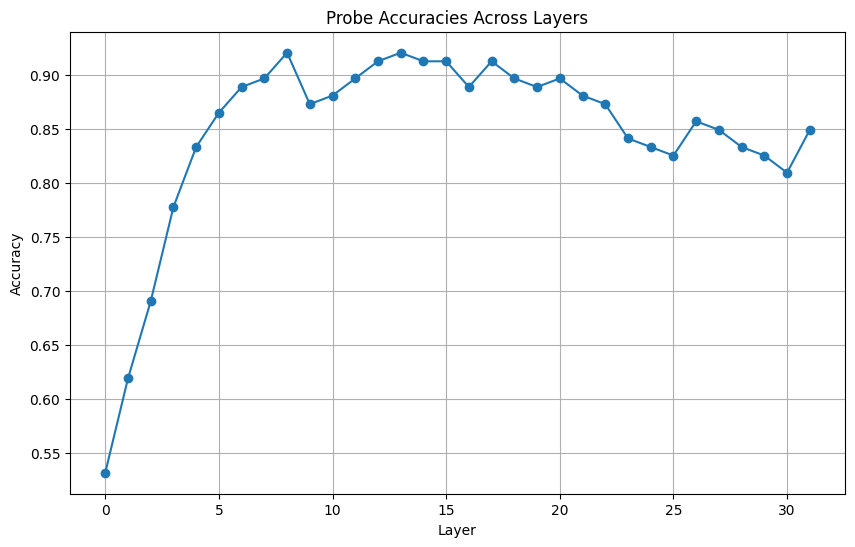

In [59]:
# graph the probe accuracies

plt.figure(figsize=(10, 6))
plt.plot(list(probe_accuracies.keys()), list(probe_accuracies.values()), marker='o')
plt.title('Probe Accuracies Across Layers')
plt.xlabel('Layer')
plt.ylabel('Accuracy')
plt.grid()
plt.show()